<a href="https://colab.research.google.com/github/Cosider24/machine-learning-fundamentals/blob/main/10-cnn-cifar10-image-classification/%D0%9A%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D1%8F_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_CIFAR_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Цель работы

Освоить применение сверточных нейронных сетей (CNN) для задач классификации изображений, а также изучить основные нюансы обучения моделей:

разделение данных на обучающую и валидационную выборки
анализ процесса обучения по графикам
выявление переобучения и недообучения
влияние архитектуры и гиперпараметров на качество модели

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [ ]:
# Названия классов из набора данных CIFAR-10
classes=['самолет', 'автомобиль', 'птица', 'кот', 'олень', 'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик']

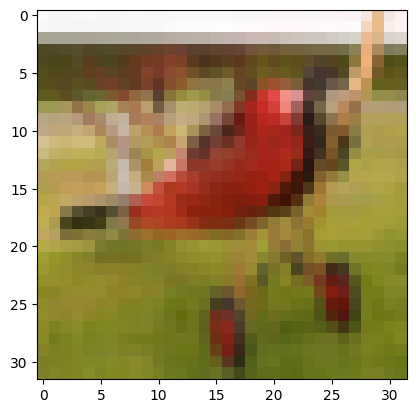

Номер класса: [0]
Тип объекта: самолет


In [ ]:
n = 35
plt.imshow(X_train[n])
plt.show()
print("Номер класса:", y_train[n])
print("Тип объекта:", classes[y_train[n][0]])

Шаг 2. Подготовьте данные

Нормализуйте изображения и преобразуйте метки классов.

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

In [ ]:
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

Шаг 3. Разделите данные

Разделите обучающую выборку на обучающую и валидационную.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

Шаг 4. Создайте сверточную нейронную сеть

Создайте модель с использованием сверточных слоев и слоев подвыборки.

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))

model.add(Flatten())

model.add(Dense(3000, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(10, activation='softmax'))

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_42 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_43 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 3000)           │     6,915,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 3000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │        30,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,964,402 (26.57 MB)

 Trainable params: 6,964,402 (26.57 MB)

 Non-trainable params: 0 (0.00 B)

Шаг 5. Скомпилируйте модель

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Шаг 6. Обучите модель

Обучите модель с использованием валидационной выборки.

In [ ]:
history = model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=10,
    validation_data=(X_val, y_val)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.4885 - loss: 1.4186 - val_accuracy: 0.5957 - val_loss: 1.1410
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6301 - loss: 1.0591 - val_accuracy: 0.6611 - val_loss: 0.9806
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6884 - loss: 0.8817 - val_accuracy: 0.6800 - val_loss: 0.9191
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7429 - loss: 0.7354 - val_accuracy: 0.7058 - val_loss: 0.8665
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7930 - loss: 0.5938 - val_accuracy: 0.7129 - val_loss: 0.8736
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8452 - loss: 0.4513 - val_accuracy: 0.7067 - val_loss: 0.9181
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8856 - loss: 0.3335 - val_accuracy: 0.7259 - val_loss: 0.9046
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9233 - loss: 0.2282 - val_accuracy: 0.

Шаг 7. Постройте графики обучения

Постройте графики точности и функции потерь.

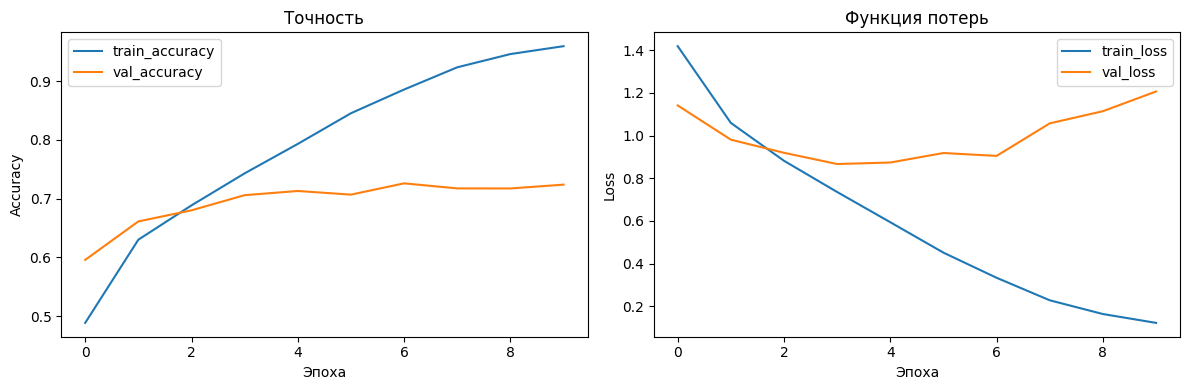

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Функция потерь')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Шаг 8. Оцените модель

Оцените качество модели на тестовой выборке.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Функция потерь: {test_loss:.4f}")
print(f"Точность: {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7078 - loss: 1.2506
Функция потерь: 1.2506
Точность: 0.7078


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Точность на тестовой выборке:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7078 - loss: 1.2506
Точность на тестовой выборке: 0.7077999711036682


# Какую роль выполняет слой Conv2D в сверточной нейронной сети?
Выполняет операцию свёртки.

# Какие признаки он извлекает из изображения?
Горизонтальные и вертикальные линии...

# Что означает параметр “количество фильтров” в слое Conv2D?
количество разных признаков, которые слой умеет искать.

# Как влияет увеличение числа фильтров на качество и сложность модели?
Качество увеличивается, признаки становятся более сложными. Требуется больше времени, памяти и растет риск переобучения.

# Что делает слой MaxPooling2D и зачем он используется после сверточных слоев?
Уменьшает размер картинки, оставляя только самые значимые значения.

# Как изменяется размер данных после последовательного применения Conv2D и MaxPooling2D?
Conv2D изменяет пространственные размеры (высоту и ширину) и увеличивает/уменьшает количество каналов. MaxPooling2D уменьшает высоту и ширину, не трогая каналы.

# Почему это важно для обучения модели?
Увеличивается скорость обучения, снижается параметр переобучения

# Зачем используется слой Flatten перед полносвязными слоями?
Он преобразует их в одномерный вектор,  слои Dense работают только с одномерными векторами

# Как по графикам accuracy и loss определить переобучение модели?
Train и Val растут либо падают вместе, при этом Val чуть выше или ниже. В случае чего используем Dropout отключая часть нейронов

# Чем сверточные CNN лучше полносвязных в работе с изображениями?
В CNN меньше параметров, не ломается при сдвиге объекта, можно обучать на малом числе параметров